# Exploratory Data Analysis

We are working with the Online Retail II dataset which can be found here: https://archive.ics.uci.edu/dataset/502/online+retail+ii.

**Given Dataset Description:**  

**InvoiceNo:** Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.  
**StockCode:** Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.  
**Description:** Product (item) name. Nominal.  
**Quantity:** The quantities of each product (item) per transaction. Numeric.  
**InvoiceDate:** Invice date and time. Numeric. The day and time when a transaction was generated.  
**UnitPrice:** Unit price. Numeric. Product price per unit in sterling (Â£).  
**CustomerID:** Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.  
**Country:** Country name. Nominal. The name of the country where a customer resides.  

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load sheets into separate dataframes
df1 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2010-2011')

# Stack the rows together and reset the index
df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
df.head()

In [ ]:
df.info()

## Data Cleaning

### Rename Columns

In [ ]:
df = df.rename(columns={'Customer ID': 'CustomerID'})
df.head()

### Check Datatypes

In [ ]:
# Check for mixed types within each object column
for col in df.columns:
    types_present = df[col].dropna().apply(type).value_counts()
    print(col, '->', types_present.to_dict())

In [ ]:
df['Invoice'] = df['Invoice'].astype(str)
df['StockCode'] = df['StockCode'].astype(str)
df['CustomerID'] = df['CustomerID'].astype('Int64')  # nullable int, keeps NaN as <NA>, no more .0
# We'll handle Description later

### Drop Duplicate Rows

In [ ]:
print(f"Duplicate Rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Length of the dataset after dropping duplicates: {len(df)}")

In [ ]:
df.info()

### Handle the Datetime Column

In [ ]:
from datetime import datetime

df['InvoiceDateTime'] = df['InvoiceDate'] 
df['InvoiceDate'] = df['InvoiceDateTime'].dt.date
df['InvoiceTime'] = df['InvoiceDateTime'].dt.time
df['InvoiceHour'] = df['InvoiceDateTime'].dt.hour
df['InvoiceDayOfWeek'] = df['InvoiceDateTime'].dt.day_name()
df['InvoiceMonth'] = df['InvoiceDateTime'].dt.to_period('M')

In [ ]:
df.head()

### Handle Missing Values

**CustomerID**

In [ ]:
df.isna().sum()

Customer ID is an important field for customer-level analysis. Hence, we can check:
- How much revenue/volume is at stake - does excluding them lose a trivial or meaningful chunk?
- Do guest orders tend to be smaller on average than identified-customer orders?

In [ ]:
missing_rows = df[df['CustomerID'].isna()]
print(f"Missing-ID row share: {len(missing_rows)/len(df):.2%}")
print(f"Missing-ID revenue share: {(missing_rows['Quantity']*missing_rows['Price']).sum() / (df['Quantity']*df['Price']).sum():.2%}")

In [ ]:
guest_avg_order = missing_rows.groupby('Invoice').apply(lambda x: (x['Quantity']*x['Price']).sum()).mean()
identified_avg_order = df[~df['CustomerID'].isna()].groupby('Invoice').apply(lambda x: (x['Quantity']*x['Price']).sum()).mean()
print(f"Guest avg order value: £{guest_avg_order:.2f}")
print(f"Identified avg order value: £{identified_avg_order:.2f}")

- 22.76% seems like a sizeable amount of missing customer IDs to just throw away. We can still use them in product-level or basket-level analysis.
- 13.6% of revenue share shows a good amount of revenue comes from unidentified customers.
- Also, the guest average order value is not very far from the identified customers' average order value.
- It would benefit to keep these transactions with missing customer ID to analyse other things.
- Since Invoice is generated for one purchase, we can use it generate the customer ID for some guests. The transactions with the same invoice can be grouped, as they would be from the same customer.
- Here's how we'll handle this: We'll create a unique pseudo ID = 'GUEST' + invoice number. Also, we'll create a binary flag 'is_guest'.
- This will help us identify guests and also handle the missing values.

In [ ]:
df['CustomerID'] = df['CustomerID'].astype('object')
missing_mask = df['CustomerID'].isna()

df['is_guest'] = missing_mask
df.loc[missing_mask, 'CustomerID'] = 'GUEST_' + df.loc[missing_mask, 'Invoice'].astype(str)

In [ ]:
# Verify
df[df['CustomerID'].astype(str).str.startswith('GUEST_')].head()

In [ ]:
# Verify
df['CustomerID'].isna().sum()

**Description**

In case of the Description column, in case time permits, we can implement a NLP customer segmentation to identify the different products purchased and analyse the product-level stats.  

In [ ]:
df['Description'].isna().sum()

Let's check if every StockCode has a unique description. If that's the case, we can use descriptions from other transactions to fill the misisng values.

In [ ]:
# How many distinct descriptions does each StockCode have?
desc_per_code = df.groupby('StockCode')['Description'].nunique()
print(desc_per_code.value_counts().sort_index())

# StockCodes with more than 1 description — worth inspecting
inconsistent_codes = desc_per_code[desc_per_code > 1].index
print(f"StockCodes with multiple descriptions: {len(inconsistent_codes)}")
df[df['StockCode'].isin(inconsistent_codes)].sort_values('StockCode')[['StockCode','Description']].drop_duplicates().head(20)

- There are 1232 stock codes with multiple descriptions.
- Notice that every legitimate product description is in ALL CAPS, while there are certain junk entries in lowercase or mixed case.
- These look like internal stock-adjustment notes typed by warehouse staff into the same free-text field, not real product descriptions. They're probably associated with adjustment/write-off transactions (damaged stock, mis-shipments, stocktake corrections) rather than genuine customer sales.
- We will replace both, the missing descriptions (NA) and the junk descriptions with the most-used descriptions from the dataset(modes).

In [ ]:
# Canonical description = most frequent Description for each StockCode
canonical_desc = df.groupby('StockCode')['Description'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)

# Missing descriptions will be filled with the description that is most used for that stockCode
# Same for junk values (values that are ued less times)
df['Description'] = df['StockCode'].map(canonical_desc)

In [ ]:
# Check remaining missing values
remaining_missing = df['Description'].isna().sum()
print(f"Remaining missing descriptions: {remaining_missing}")
df[df['Description'].isna()]

In [ ]:
df[df['Description'].isna()]['CustomerID'].str.startswith('GUEST').sum()

In [ ]:
df[df['Description'].isna()]['Price'].value_counts()

In [ ]:
df[df['Description'].isna()]['Quantity'].value_counts()

- There are still 363 rows with missing descriptions. This means these StockCodes do not have any value for any of the transactions done. 
- Note that the Customer ID for all of them was missing in the dataset (GUEST customers) and also the Price is 0 for all these entries.
- These are probably manual entries or fixes done by the staff.
- As the price is 0, they will not be helpful for revenue analysis and with no description, we cannot identify the products either.
- We can safely drop all these rows from our analysis. 

In [ ]:
# These 359 rows carry no real product identity or price — treat as noise,
# consistent with the stock-adjustment/non-product handling done earlier
df = df[~df['Description'].isna()]

### Analyse each column to identify any issues

In [ ]:
df.head()

In [ ]:
df['Invoice'] = df['Invoice'].astype(str)

# Extract any leading non-digit characters
invoice_prefix = df['Invoice'].str.extract(r'^([^\d]*)')[0]
print(invoice_prefix.value_counts())

In [ ]:
df[df['Invoice'].astype(str).str.startswith('A')]

In [ ]:
df = df[~df['Invoice'].str.startswith('A')]

- There are only 6 entries with Invoice numbers starting with 'A'. 
- Note that the stockCode is B for them all, quantity is 1 and the price is negative (except 1). Also, all of them are guest accounts, no customer numbers.
- These are internal accounting write-offs, not customer transactions — a company marking a debt as uncollectible.
- We can drop these 6 rows. They're not sales, not returns of goods, not guest orders — they're just finance department bookkeeping.

In [ ]:
print(df['Invoice'].str.len().value_counts())

In [ ]:
df[(df['Invoice'].str.len() == 7) & (~df['Invoice'].str.startswith('C')) & (~df['Invoice'].str.startswith('A'))]

Note that now the only 7-letter Invoice numbers remaining are the Cancelled orders starting with a C.

Let's check the Quantity column to see any discrepancies.

In [ ]:
invoice_prefix = df['Invoice'].str.extract(r'^([^\d]*)')[0]

for prefix in invoice_prefix.unique():
    subset = df[invoice_prefix == prefix]
    print(f"Prefix '{prefix}': {len(subset)} rows, Quantity range [{subset['Quantity'].min()}, {subset['Quantity'].max()}]")

We can see there are some invoices that are not cancelled (regular invoices) but still have a negative Quantity and there are Cancelled invoices with a positive quantity (of 1).  
Let's check them one by one.

In [ ]:
df[(df['Invoice'].astype(str).str.startswith('C')) & (df['Quantity'] > 0)]

In [ ]:
df = df[~((df['Invoice'].str.startswith('C')) & (df['Quantity'] > 0))]

- Note that the StockCode is M and the description is Manual.
- This is used by the online retailer to manually key in miscellaneous charges, office adjustments, or custom fees onto an invoice.
- We will look into such codes further down in the notebook.
- For now, we can safely drop this one row as it represents non-product transactions, administrative fees, or manual ledger adjustments rather than physical inventory items.

Let's check the other case now where the quantity is negative for a regular invoice code. 

In [ ]:
df[(df['Invoice'].str.len() == 6) & (df['Quantity'] < 0)]

Notice how the Price for all of them seems to be 0 and the customer ID is a guest ID, so these are not saved customers. We can verify if it's true for all transactions.

In [ ]:
# Verify if all such transactions are guest transactions
df1 = df[(df['Invoice'].str.len() == 6) & (df['Quantity'] < 0)]
df1[~df1['CustomerID'].str.startswith('GUEST')]

In [ ]:
# Verify if the price is 0.0 for such transactions
df[(df['Invoice'].str.len() == 6) & (df['Quantity'] < 0) & (df['Price'] != 0.0)]

In [ ]:
df['is_stock_adjustment'] = (
    (df['Quantity'] < 0) &
    (df['Price'] == 0) &
    (~df['Invoice'].str.startswith('C'))
)
print(df['is_stock_adjustment'].sum())

In [ ]:
df = df[~df['is_stock_adjustment']]
df.drop(['is_stock_adjustment'], axis=1, inplace=True)

- These 3393 rows appear to be internal stock-loss adjustments, identified by zero price, negative quantity, non-cancellation invoice, and 100% guest/unidentified customer. 
- These should be excluded from all customer-facing and revenue analysis as they're not purchases, not returns of purchases, and not attributable to any real customer.
- We can safely drop these rows.

We have seen above there are certain invoices starting with a 'C'. These are product cancellations or returns.  
We will create a is_cancellation flag to make it easier for us to analyse purchases v/s returns separately.

In [ ]:
df['is_cancellation'] = df['Invoice'].str.startswith('C')

In [ ]:
df.head()

Let's move onto the StockCode column now. We can look at the different types of stock codes in our dataset.

In [ ]:
# Real product codes are typically 5-digit numeric, optionally with 1-2 trailing letters
import re

def code_pattern_type(code):
    code = str(code)
    if re.match(r'^\d{5}[A-Za-z]{0,2}$', code):
        return 'standard_product'
    else:
        return 'non_standard'

df['stockcode_type'] = df['StockCode'].apply(code_pattern_type)
print(df['stockcode_type'].value_counts())

# Look at what the non-standard codes actually are
non_standard = df[df['stockcode_type'] == 'non_standard']
print(non_standard[['StockCode', 'Description']].value_counts())

- From the above results, it can be seen that some of the stock codes can be excluded completely. There is no real transaction value and they cannot contribute to any type of analysis.  
List of such stock codes: S (samples, given away — no real transaction value), BANK CHARGES, ADJUST/ADJUST2 (internal staff stock corrections), AMAZONFEE, CRUK (commission/fee), TEST001/TEST002 (literal test data), M, m (Manual Entries)

- Some of the codes can be used for revenue calculations, however should be excluded from product-level or basket-level analysis.
List of such stock codes: POST/DOT (Postage or Shipping Charges), C2 (Carriage), D (Discount), gift_000x (Gift vouchers).

- The remaining codes like DCGSxxxx or PADS can be left as products. They're genuine product codes flagged by the strict regex pattern. 

In [ ]:
# Rows to drop entirely — not real, interpretable customer transactions
drop_codes = ['S', 'BANK CHARGES', ' BANK CHARGES', 'BANK CHARGES ', 'ADJUST', 'ADJUST ', 'ADJUST2',
              'AMAZONFEE', 'CRUK', 'TEST001', 'TEST002', 'M', 'm']
df = df[~df['StockCode'].isin(drop_codes)]

# Non-product codes: keep in revenue, exclude from product/basket analysis
non_product_revenue_codes = ['POST', 'DOT', 'C2', 'D'] + \
    [c for c in df['StockCode'].unique() if str(c).startswith('gift_')]
df['is_non_product'] = df['StockCode'].isin(non_product_revenue_codes)

df_products_only = df[~df['is_non_product']]   # for basket & product analysis
# df_clean itself remains your revenue-accurate, customer-level base

In [ ]:
df.info()

In [ ]:
# Look at what the standard codes actually are
standard = df[df['stockcode_type'] == 'standard_product']
print(standard[['StockCode', 'Description']].value_counts())

Notice that the Description in some of the standard codes is incorrect as well. We'll handle this while handling the Description column separately. 

In [ ]:
df.head()

In [ ]:
df.isna()

## Analysis and Visualisations

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

### Country

In [102]:
df['Country'].value_counts(normalize=True)

Country
United Kingdom          0.917818
EIRE                    0.017114
Germany                 0.016840
France                  0.013630
Netherlands             0.004989
Spain                   0.003641
Switzerland             0.003089
Belgium                 0.003024
Portugal                0.002444
Australia               0.001832
Channel Islands         0.001597
Italy                   0.001463
Sweden                  0.001319
Norway                  0.001261
Cyprus                  0.001124
Finland                 0.001017
Austria                 0.000910
Denmark                 0.000775
Unspecified             0.000730
Greece                  0.000645
Japan                   0.000546
USA                     0.000520
Poland                  0.000513
United Arab Emirates    0.000484
Israel                  0.000358
Hong Kong               0.000340
Singapore               0.000323
Malta                   0.000287
Canada                  0.000222
Iceland                 0.000216
RS

- 91% of the data consists of transactions made in the UK. The rest 9% between all other countries.
- We will consider the entire data for further analysis. Country-level analysis cannot be done with such sparse data from other countries.

### Order size

In [116]:
df['is_guest'].value_counts()

is_guest
False    796667
True     231238
Name: count, dtype: int64

In [121]:
guests = df[df['is_guest']]
print(f"Percentage of guests: {len(guests)/len(df):.2%}")
print(f"Revenue share of guests: {(guests['Quantity'] * guests['Price']).sum() / (df['Quantity'] * df['Price']).sum():.2%}")

Percentage of guests: 22.50%
Revenue share of guests: 14.83%


In [129]:
avg_guest_order = guests.groupby('Invoice').apply(lambda x: (x['Quantity']*x['Price']).sum()).mean()
avg_identified_order = df[~df['is_guest']].groupby('Invoice').apply(lambda x: (x['Quantity']*x['Price']).sum()).mean()
avg_order_size = df.groupby('Invoice').apply(lambda x: (x['Quantity']*x['Price']).sum()).mean()
print(f"Guest average order value: £{avg_guest_order:.2f}")
print(f"Identified average order value: £{avg_identified_order:.2f}")
print(f"Overall average order value: £{avg_order_size:.2f}")

Guest average order value: £574.20
Identified average order value: £372.38
Overall average order value: £392.85


- Note that the percentage of guests and the revenue share have now changed as we dropped some rows from our analysis during clean-up.
- Guest vs identified order value flip is interesting — guests order more per transaction (£574 vs £372) but contribute less revenue overall because there are fewer of them.

### Top Products

In [160]:
# Top products by revenue
product_df = df[~df['is_non_product']]
product_df = product_df.groupby(['StockCode', 'Description']).apply(lambda x: (x['Quantity']*x['Price']).sum()).reset_index()
product_df.rename(columns = {0: 'TotalSpent'}, inplace=True)
print(f"Top 10 products by revenue: ")
stock_df.sort_values('TotalSpent', ascending=False).head(10)

Top 10 products by revenue: 


,StockCode,Description,TotalSpent
1976,22423,REGENCY CAKESTAND 3 TIER,314045.02
5818,DOT,DOTCOM POSTAGE,309844.10
5201,85123A,WHITE HANGING HEART T-LIGHT HOLDER,248159.10
3874,47566,PARTY BUNTING,147079.73
5167,85099B,JUMBO BAG RED RETROSPOT,143834.41
4827,84879,ASSORTED COLOUR BIRD ORNAMENT,128550.42
1548,22086,PAPER CHAIN KIT 50'S CHRISTMAS,116298.59
5820,POST,POSTAGE,110430.41
4230,79321,CHILLI LIGHTS,79905.13
4407,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,70969.95


In [159]:
# Top products by Volume
top_products_vol = df.groupby(['StockCode', 'Description'])['Quantity'].sum().sort_values(ascending=False).reset_index()
print("Top 10 products by volume: ")
top_products_vol.head(10)

Top 10 products by volume: 


,StockCode,Description,Quantity
0,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,104546
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,90510
2,84879,ASSORTED COLOUR BIRD ORNAMENT,79579
3,85099B,JUMBO BAG RED RETROSPOT,76095
4,17003,BROCADE RING PURSE,69639
5,21977,PACK OF 60 PINK PAISLEY CAKE CASES,55842
6,84991,60 TEATIME FAIRY CAKE CASES,53678
7,22197,SMALL POPCORN HOLDER,48234
8,21212,PACK OF 72 RETROSPOT CAKE CASES,47695
9,21212,PACK OF 72 RETRO SPOT CAKE CASES,46079


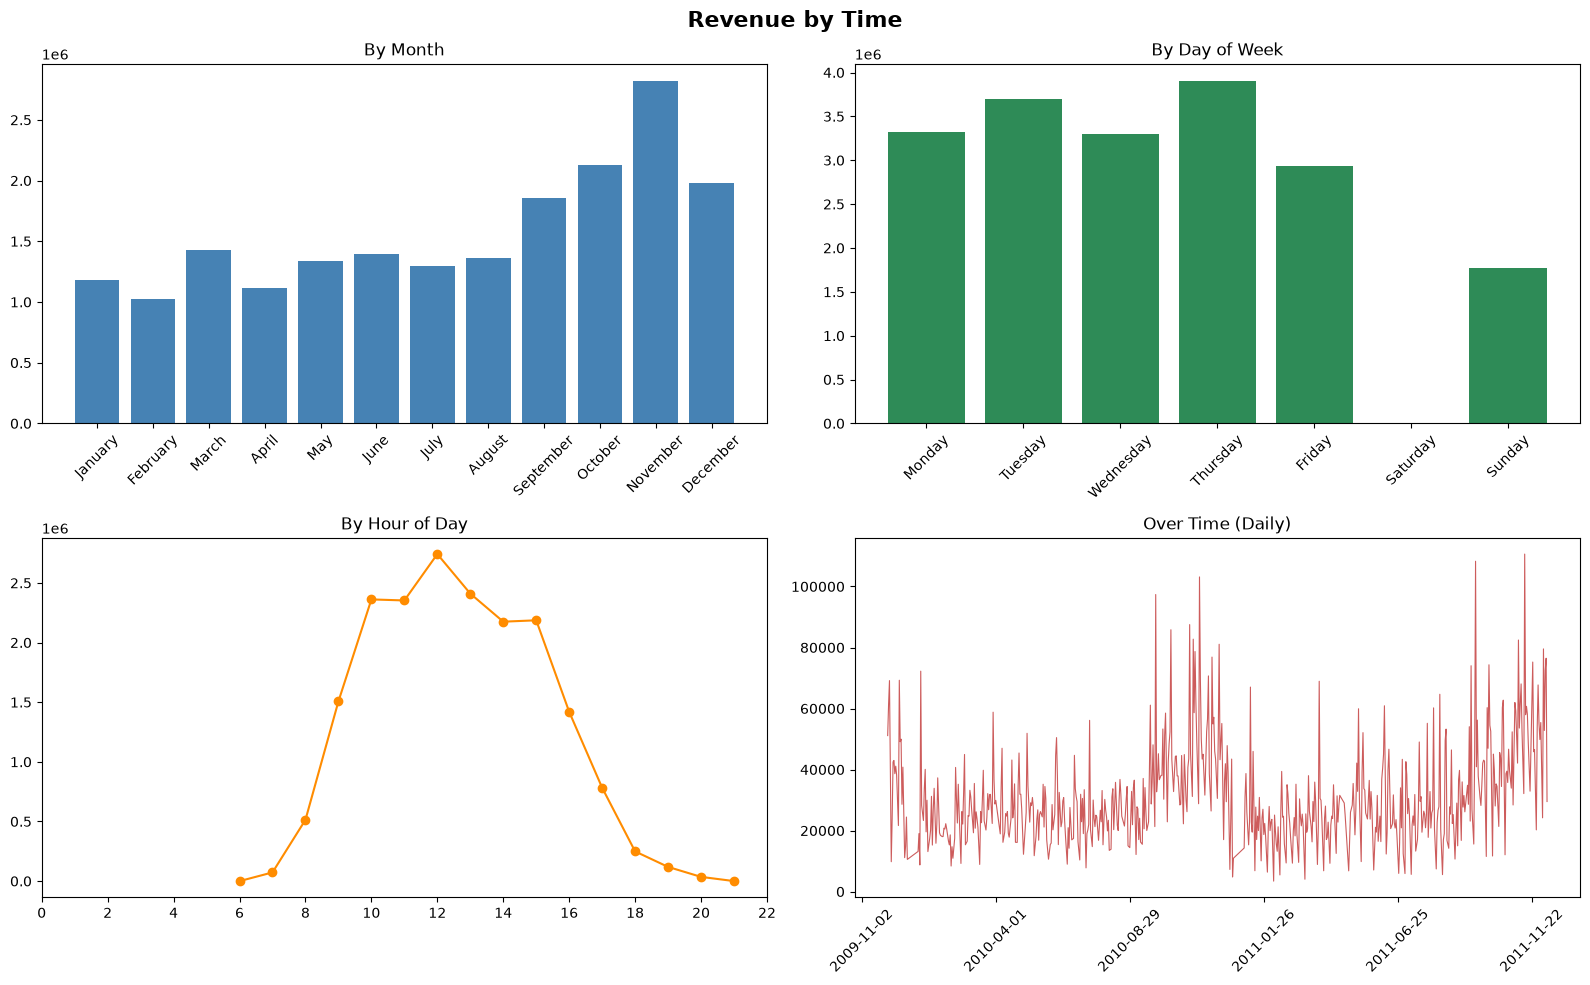

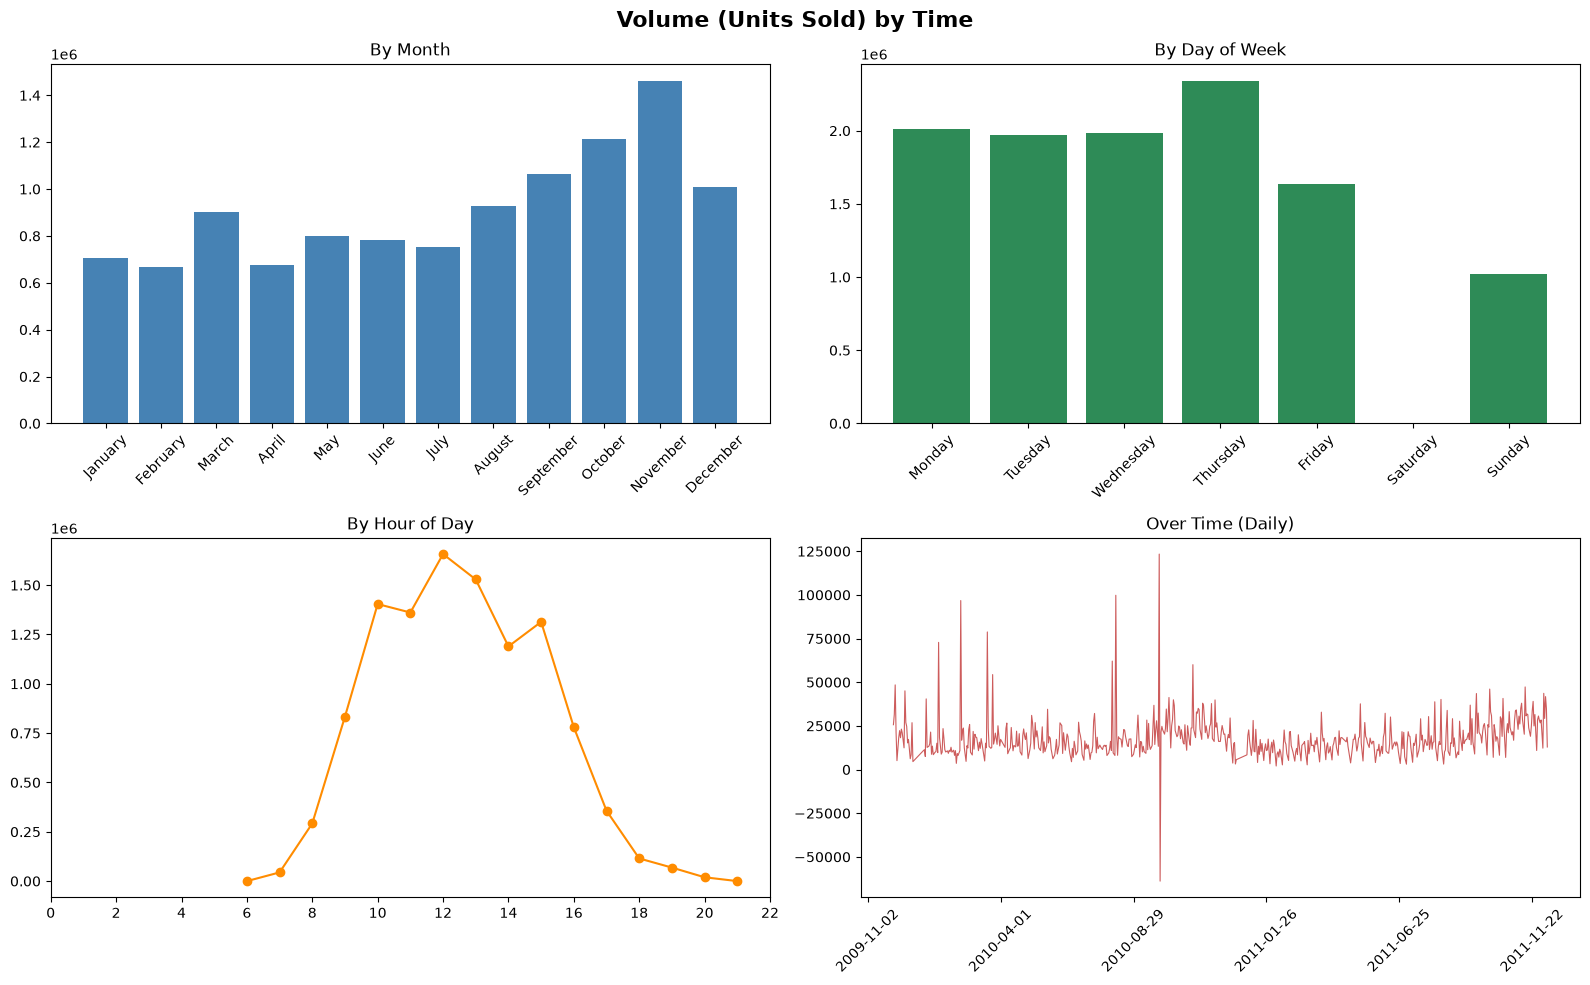

In [172]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Revenue column (net — includes cancellations, so returns correctly reduce revenue)
df['Revenue'] = df['Quantity'] * df['Price']

# Derived time features
df['Month'] = df['InvoiceDateTime'].dt.month_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Use a clean, transactional-only view for these charts (drop non-product rows
# like postage/fees so the *shape* of the trend reflects real product activity;
# switch to `df` if you want total revenue including postage/vouchers instead)
plot_df = df[~df.get('is_non_product', False)] if 'is_non_product' in df.columns else df


def plot_time_grid(metric_col, agg_func, title):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    # 1. By Month (seasonality across the year, aggregated over both years)
    monthly = plot_df.groupby('Month')[metric_col].agg(agg_func).reindex(month_order)
    axes[0, 0].bar(monthly.index, monthly.values, color='steelblue')
    axes[0, 0].set_title('By Month')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. By Day of Week
    weekly = plot_df.groupby('InvoiceDayOfWeek')[metric_col].agg(agg_func).reindex(day_order)
    axes[0, 1].bar(weekly.index, weekly.values, color='seagreen')
    axes[0, 1].set_title('By Day of Week')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. By Hour of Day
    hourly = plot_df.groupby('InvoiceHour')[metric_col].agg(agg_func)
    axes[1, 0].plot(hourly.index, hourly.values, marker='o', color='darkorange')
    axes[1, 0].set_title('By Hour of Day')
    axes[1, 0].set_xticks(range(0, 24, 2))

    # 4. Full timeline (daily trend across the whole 2-year period)
    daily = plot_df.groupby('InvoiceDate')[metric_col].agg(agg_func)
    axes[1, 1].plot(daily.index, daily.values, color='indianred', linewidth=0.8)
    axes[1, 1].set_title('Over Time (Daily)')
    axes[1, 1].xaxis.set_major_locator(mticker.MaxNLocator(8))
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


# Revenue grid
plot_time_grid('Revenue', 'sum', 'Revenue by Time')

# Volume grid (using Quantity)
plot_time_grid('Quantity', 'sum', 'Volume (Units Sold) by Time')

In [166]:
df['DayOfWeek'].value_counts()

DayOfWeek
Thursday     195162
Tuesday      190867
Monday       182812
Wednesday    176571
Friday       149205
Sunday       132888
Saturday        400
Name: count, dtype: int64

- It can be seen that the highest revenue made and the volume sold was in the month of November, followed by October, September and December.
- This shows a seasonal trend in sales. Sales increase around Christmas.
- Another interesting finding is that most of the transactions are made during the afternoon hours between 10am to 4pm.
- There are virtually no transactions betwwen midnight and 6am.
- This is probably because most of the customers of this company are wholesalers, who probably place orders during business hours.
- It can also be seen that the sales on Saturday are close to 0. There are negligible transactions made on Saturday. It could be possible that the store is closed on Saturdays. 